# Point selection: 3 furthest from centreline — parallel-line visualisation

For each scope region we:
1. Pick the **3 furthest** bank points from the centreline for each year
2. Draw a **parallel line** at the mean dist of those 3 points (same colour as the year)
3. Overlay the **scope region boundary** as context

Regions are filtered to those with **≥ 5 m shift between every consecutive pair of timestamps** — so the movement is unambiguously visible.

In [1]:
import sys
sys.path.insert(0, '../../')

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from shapely import offset_curve
from shapely.geometry import MultiPoint

from src import paths as PATHS

RAW_GPKG   = PATHS.DATA_DIR / '01_raw/erosion/wocu_output_fase2_20260210.gpkg'
MIN_SHIFT  = 5.0   # metres — minimum shift required between each pair of timestamps

In [2]:
pts    = gpd.read_file(RAW_GPKG, layer='punten_oever')
cl     = gpd.read_file(RAW_GPKG, layer='centrelines')
scope  = gpd.read_file(RAW_GPKG, layer='vlakken_scope')

cl_lookup    = cl.set_index('position_id')['geometry'].to_dict()
scope_lookup = scope.set_index('position_id')['geometry'].to_dict()

print(f'Bank points  : {len(pts):,}')
print(f'Centrelines  : {len(cl):,}')
print(f'Scope regions: {len(scope):,}')
print(f'Scope cols   : {list(scope.columns)}')

Bank points  : 4,844,655
Centrelines  : 12,130
Scope regions: 12,130
Scope cols   : ['position_id', 'waterlichaam', 'geometry']


In [3]:
# ── Find regions with exactly 3 timestamps and ≥ MIN_SHIFT m shift at each step ──

def mean_dist_furthest3(group):
    return group.nlargest(3, 'dist')['dist'].mean()

# Compute mean-dist-furthest-3 per (location_id, date)
agg = (
    pts.groupby(['location_id', 'dtm_date'])
       .apply(mean_dist_furthest3, include_groups=False)
       .reset_index(name='mean_dist_f3')
)

# Keep only regions with exactly 3 timestamps
ts_counts = agg.groupby('location_id')['dtm_date'].nunique()
agg = agg[agg['location_id'].isin(ts_counts[ts_counts == 3].index)].copy()
agg = agg.sort_values(['location_id', 'dtm_date'])

# Compute shifts
agg['rank'] = agg.groupby('location_id').cumcount()  # 0, 1, 2
wide = agg.pivot(index='location_id', columns='rank', values='mean_dist_f3')
wide.columns = ['d_t1', 'd_t2', 'd_t3']
wide['shift_t1t2'] = (wide['d_t2'] - wide['d_t1']).abs()
wide['shift_t2t3'] = (wide['d_t3'] - wide['d_t2']).abs()

qualifying = wide[(wide['shift_t1t2'] >= MIN_SHIFT) & (wide['shift_t2t3'] >= MIN_SHIFT)].copy()
qualifying = qualifying.sort_values('shift_t1t2', ascending=False)

print(f'Regions with 3 timestamps          : {len(wide):,}')
print(f'Regions with ≥{MIN_SHIFT} m shift each step: {len(qualifying):,}')
print()
print(qualifying.head(10).round(2))

Regions with 3 timestamps          : 9,414
Regions with ≥5.0 m shift each step: 774

                    d_t1    d_t2    d_t3  shift_t1t2  shift_t2t3
location_id                                                     
rijn_l_5440_5450  327.40  115.42  332.90      211.98      217.49
rijn_l_6030_6040  293.29  101.59  245.18      191.70      143.58
rijn_l_5970_5980  288.04   97.95  288.79      190.09      190.84
rijn_l_5960_5970  285.08  100.53  285.75      184.56      185.22
rijn_l_6010_6020  280.87  100.15  283.20      180.71      183.05
rijn_l_5920_5930  280.75  100.10  279.25      180.65      179.15
rijn_l_5980_5990  270.58  100.08  269.50      170.50      169.42
rijn_l_5990_6000  270.31  100.91  272.86      169.41      171.96
rijn_l_6020_6030  266.00  100.83  311.92      165.17      211.08
rijn_l_5950_5960  261.00  100.00  262.92      161.00      162.92


In [4]:
# ── Pick 4 representative examples spread across clusters ──

CLUSTERS = ['rijn', 'ijssel', 'maas', 'neder']
selected = []
for cluster in CLUSTERS:
    matches = [lid for lid in qualifying.index if cluster in lid]
    if matches:
        selected.append(matches[0])

# Pad to 4 if some clusters had no match
for lid in qualifying.index:
    if lid not in selected:
        selected.append(lid)
    if len(selected) == 4:
        break

print('Selected regions:')
print(qualifying.loc[selected].round(2))

Selected regions:
                         d_t1    d_t2    d_t3  shift_t1t2  shift_t2t3
location_id                                                          
rijn_l_5440_5450       327.40  115.42  332.90      211.98      217.49
ijssel1_r_2190_2200    116.50   51.42   57.33       65.08        5.92
maas2_r_2750_2760       71.19  163.99  141.71       92.80       22.28
nederrijn_r_8050_8060   76.58  181.43  171.42      104.85       10.01


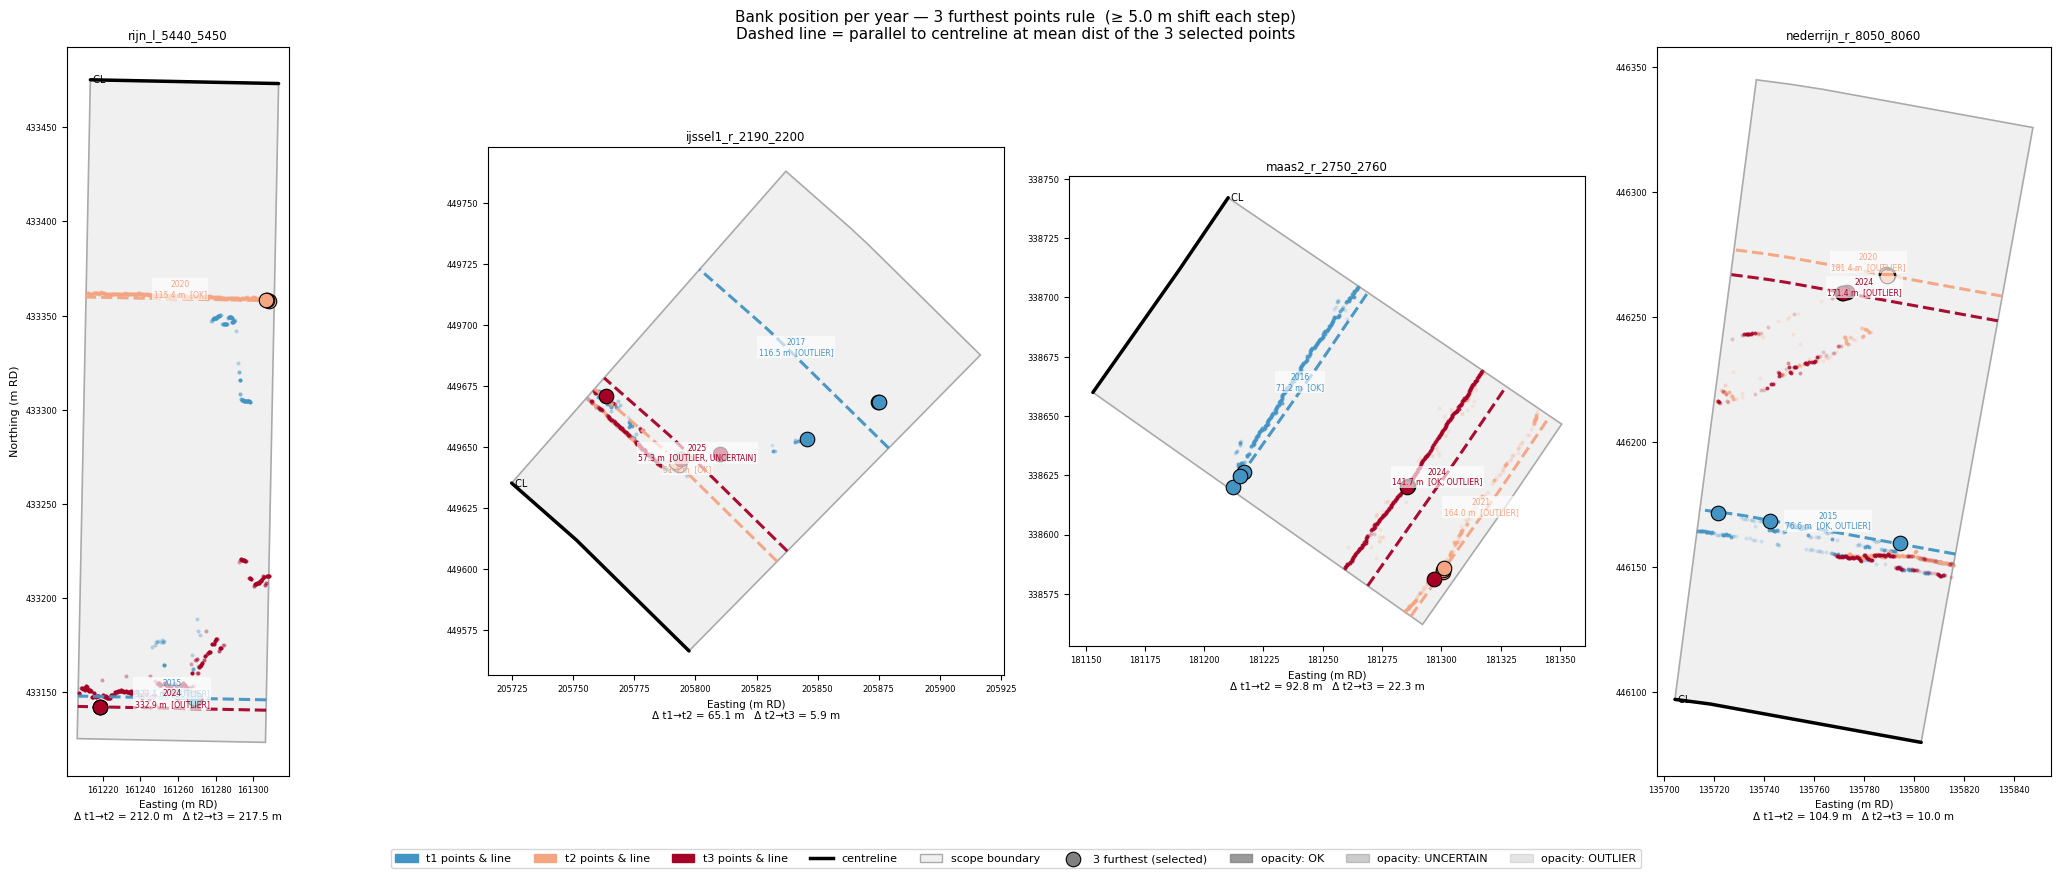

In [5]:
def offset_toward_points(centreline, dist, bank_pts_geom):
    """Offset centreline by dist toward the side where the bank points lie."""
    centroid = MultiPoint(list(bank_pts_geom)).centroid
    left  = offset_curve(centreline,  dist)
    right = offset_curve(centreline, -dist)
    if left is None or left.is_empty:
        return right
    if right is None or right.is_empty:
        return left
    mid_left  = left.interpolate(0.5, normalized=True)
    mid_right = right.interpolate(0.5, normalized=True)
    return left if mid_left.distance(centroid) < mid_right.distance(centroid) else right


def vvr_backline_distance(cline, vvr_union):
    """Return (distance_m, backline_point) for the VVR backline.

    Shoots a perpendicular ray from the midpoint of *cline* in both directions.
    Uses whichever direction has the most crossings with *vvr_union*, then takes
    the furthest crossing on that ray — the outer edge of the VVR band (backline).

    Returns (None, None) if no crossing is found.
    """
    import numpy as np
    from shapely.geometry import LineString as _LS, Point as _Pt

    if vvr_union is None or vvr_union.is_empty:
        return None, None

    RAY_LEN   = 5000
    mid_param = cline.length / 2
    mid_pt    = cline.interpolate(mid_param)
    eps       = min(1.0, cline.length * 0.01)
    pt_before = cline.interpolate(max(0.0, mid_param - eps))
    pt_after  = cline.interpolate(min(cline.length, mid_param + eps))
    dx = pt_after.x - pt_before.x
    dy = pt_after.y - pt_before.y
    dn = np.hypot(dx, dy)
    px, py = -dy / dn, dx / dn   # unit left-perpendicular

    def _ray(ddx, ddy):
        return _LS([(mid_pt.x, mid_pt.y),
                    (mid_pt.x + ddx * RAY_LEN, mid_pt.y + ddy * RAY_LEN)])

    def _sorted_crossings(ray):
        inter = ray.intersection(vvr_union)
        if inter.is_empty:
            return []
        origin = _Pt(ray.coords[0])
        if inter.geom_type == 'Point':
            pts_ = [inter]
        elif inter.geom_type == 'MultiPoint':
            pts_ = list(inter.geoms)
        elif inter.geom_type == 'GeometryCollection':
            pts_ = [g for g in inter.geoms if g.geom_type == 'Point']
        else:
            pts_ = [_Pt(c) for c in inter.coords] if hasattr(inter, 'coords') else []
        return sorted(pts_, key=lambda p: origin.distance(p))

    cl = _sorted_crossings(_ray( px,  py))
    cr = _sorted_crossings(_ray(-px, -py))
    crossings = cl if len(cl) >= len(cr) else cr

    if not crossings:
        return None, None

    pt = crossings[-1]   # furthest crossing = backline
    return cline.distance(pt), pt


YEAR_COLORS  = ['#4393c3', '#f4a582', '#a50026']   # t1 blue, t2 salmon, t3 red
STATUS_ALPHA = {'OK': 0.80, 'OUTLIER': 0.20, 'UNCERTAIN': 0.40}

fig, axes = plt.subplots(1, len(selected),
                         figsize=(5.5 * len(selected), 8),
                         constrained_layout=True)

for col, loc_id in enumerate(selected):
    ax    = axes[col]
    grp   = pts[pts['location_id'] == loc_id].copy()
    dates = sorted(grp['dtm_date'].unique())
    cline = cl_lookup.get(loc_id)
    sgeom = scope_lookup.get(loc_id)

    ax.set_aspect('equal')
    ax.set_title(loc_id, fontsize=8.5, pad=5)
    ax.tick_params(labelsize=6)
    if col == 0:
        ax.set_ylabel('Northing (m RD)', fontsize=8)
    ax.set_xlabel('Easting (m RD)', fontsize=8)

    # ── scope boundary ────────────────────────────────────────────────
    if sgeom is not None:
        bx, by = sgeom.exterior.xy
        ax.fill(bx, by, fc='#f0f0f0', ec='#aaaaaa', linewidth=1.2,
                zorder=1, label='scope boundary')

    # ── centreline ────────────────────────────────────────────────────
    if cline is not None:
        xs, ys = cline.xy
        ax.plot(xs, ys, color='black', linewidth=2.5, zorder=5,
                solid_capstyle='round')
        ax.text(xs[-1], ys[-1], ' CL', fontsize=7, color='black',
                va='center', zorder=6)

    for d_idx, date in enumerate(dates):
        color  = YEAR_COLORS[d_idx]
        yr_grp = grp[grp['dtm_date'] == date]

        # scatter all points (opacity = status)
        for status, sub in yr_grp.groupby('status'):
            alpha = STATUS_ALPHA.get(status, 0.3)
            ax.scatter(sub.geometry.x, sub.geometry.y,
                       c=color, s=8, alpha=alpha, linewidths=0, zorder=3)

        # 3 furthest points
        chosen    = yr_grp.nlargest(3, 'dist')
        mean_dist = chosen['dist'].mean()
        statuses  = ', '.join(sorted(chosen['status'].unique()))

        ax.scatter(chosen.geometry.x, chosen.geometry.y,
                   c=color, s=110, edgecolors='black', linewidths=0.8,
                   zorder=8)

        # parallel line at mean dist of chosen 3
        if cline is not None:
            offset_line = offset_toward_points(cline, mean_dist, chosen.geometry)
            if offset_line is not None and not offset_line.is_empty:
                ox, oy = offset_line.xy
                ax.plot(ox, oy, color=color, linewidth=2.2, linestyle='--',
                        zorder=6, alpha=0.95)
                mid = offset_line.interpolate(0.5, normalized=True)
                ax.text(mid.x, mid.y,
                        f'{date}\n{mean_dist:.1f} m  [{statuses}]',
                        fontsize=5.5, color=color, ha='center', va='bottom',
                        zorder=9,
                        bbox=dict(fc='white', ec='none', alpha=0.65, pad=1))

    # annotate shifts
    info = qualifying.loc[loc_id]
    ax.set_xlabel(
        f'Easting (m RD)\nΔ t1→t2 = {info["shift_t1t2"]:.1f} m   '
        f'Δ t2→t3 = {info["shift_t2t3"]:.1f} m',
        fontsize=7.5
    )

# ── legend ────────────────────────────────────────────────────────────
year_patches = [
    mpatches.Patch(color=YEAR_COLORS[i], label=f't{i+1} points & line')
    for i in range(3)
]
other = [
    plt.Line2D([0], [0], color='black', linewidth=2.5, label='centreline'),
    mpatches.Patch(fc='#f0f0f0', ec='#aaaaaa', label='scope boundary'),
    plt.scatter([], [], s=110, c='grey', edgecolors='black', linewidths=0.8,
                label='3 furthest (selected)'),
    mpatches.Patch(color='grey', alpha=0.80, label='opacity: OK'),
    mpatches.Patch(color='grey', alpha=0.40, label='opacity: UNCERTAIN'),
    mpatches.Patch(color='grey', alpha=0.20, label='opacity: OUTLIER'),
]
fig.legend(handles=year_patches + other,
           loc='lower center', ncol=9, fontsize=8,
           bbox_to_anchor=(0.5, -0.06), frameon=True)

fig.suptitle(
    f'Bank position per year — 3 furthest points rule  (≥ {MIN_SHIFT} m shift each step)\n'
    'Dashed line = parallel to centreline at mean dist of the 3 selected points',
    fontsize=11, y=1.02
)
plt.show()

In [6]:
# Numeric summary for the plotted regions
rows = []
for loc_id in selected:
    grp   = pts[pts['location_id'] == loc_id]
    dates = sorted(grp['dtm_date'].unique())
    for d_idx, date in enumerate(dates):
        yr_grp = grp[grp['dtm_date'] == date]
        chosen = yr_grp.nlargest(3, 'dist')
        rows.append({
            'region'   : loc_id,
            'timestamp': f't{d_idx+1} ({date})',
            'mean_dist': round(chosen['dist'].mean(), 2),
            'status'   : ', '.join(sorted(chosen['status'].unique())),
        })

df = pd.DataFrame(rows)
pivot = df.pivot_table(index='region', columns='timestamp',
                       values='mean_dist', aggfunc='first')
t_cols = sorted(pivot.columns)
pivot['Δ t1→t2 (m)'] = (pivot[t_cols[1]] - pivot[t_cols[0]]).round(2)
pivot['Δ t2→t3 (m)'] = (pivot[t_cols[2]] - pivot[t_cols[1]]).round(2)
pivot['Δ t1→t3 (m)'] = (pivot[t_cols[2]] - pivot[t_cols[0]]).round(2)

print('Mean dist (m) of 3 furthest points — selected regions:')
print(pivot.to_string())

print('\nStatus of selected 3 furthest points:')
spivot = df.pivot_table(index='region', columns='timestamp',
                        values='status', aggfunc='first')
print(spivot.to_string())

Mean dist (m) of 3 furthest points — selected regions:
timestamp              t1 (2015)  t1 (2016)  t1 (2017)  t2 (2020)  t2 (2021)  t2 (2022)  t3 (2024)  t3 (2025)  Δ t1→t2 (m)  Δ t2→t3 (m)  Δ t1→t3 (m)
region                                                                                                                                              
ijssel1_r_2190_2200          NaN        NaN      116.5        NaN        NaN      51.42        NaN      57.33          NaN          NaN          NaN
maas2_r_2750_2760            NaN      71.19        NaN        NaN     163.99        NaN     141.71        NaN          NaN          NaN          NaN
nederrijn_r_8050_8060      76.58        NaN        NaN     181.43        NaN        NaN     171.42        NaN          NaN          NaN          NaN
rijn_l_5440_5450          327.40        NaN        NaN     115.42        NaN        NaN     332.90        NaN          NaN          NaN          NaN

Status of selected 3 furthest points:
timestamp   

---
## Part 2 — VVR boundary exploration

**Domain logic:**
- The VVR (*Vrijruimte voor de Rivier*) is the zone the river is permitted to use.  
- The inner boundary of the VVR is the *signaleringlijn*. If the bank reaches this line, the full VVR has been consumed.  
- `distance_to_signaleringlijn` in `vvr_all_results` records how many metres of free space remain.  
- `Vlak_Vrijeruimte_ln.gpkg / Vrijruimte_NVO_ln` contains the actual boundary line geometries.

We explore:
1. What columns the VVR layers contain and how they link to scope regions.  
2. Which scope regions in our bank-point data also have VVR data.  
3. A side-by-side plot: bank points + bank-position lines **plus** the VVR boundary for each region.

In [7]:
PROCESSED_GPKG = PATHS.DATA_DIR / '02_processed/erosion/wocu_post_processed_fase2_20260223.gpkg'
VVR_GPKG       = PATHS.DATA_DIR / '01_raw/scope/Vlak_Vrijeruimte_ln.gpkg'

# ── VVR boundary lines ────────────────────────────────────────────────────────
vvr_ln = gpd.read_file(VVR_GPKG)
print('=== Vrijruimte_NVO_ln ===')
print(f'Shape  : {vvr_ln.shape}')
print(f'CRS    : {vvr_ln.crs}')
print(f'Columns: {list(vvr_ln.columns)}')
print(vvr_ln.head(4).to_string())
print()

# ── VVR time-series results (no geometry) ────────────────────────────────────
vvr_ts = gpd.read_file(PROCESSED_GPKG, layer='vvr_all_results')
print('=== vvr_all_results ===')
print(f'Shape  : {vvr_ts.shape}')
print(f'Columns: {list(vvr_ts.columns)}')
print(vvr_ts.head(6).to_string())
print()
print(f'Unique position_ids: {vvr_ts["position_id"].nunique()}')
print(f'Years covered      : {sorted(vvr_ts["annum"].unique())}')

=== Vrijruimte_NVO_ln ===
Shape  : (105, 9)
CRS    : EPSG:28992
Columns: ['datummutatie', 'bron', 'status', 'objectnaam', 'rwsdienst', 'waterlichaam', 'opmerkingen', 'gdb_geomattr_data', 'geometry']
               datummutatie         bron       status                         objectnaam rwsdienst       waterlichaam opmerkingen                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

/Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/.venv/lib/python3.12/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'Vlak_Vrijeruimte_ln.gpkg': 'Vrijruimte_nevengeul_ln' (default), 'Vrijruimte_NVO_ln'. Specify layer parameter to avoid this warning.
  result = read_func(
/Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/.venv/lib/python3.12/site-packages/pyogrio/raw.py:200: RuntimeWarning: Non-conformant content for record 1 in column datummutatie, 2022-07-04T00:00:00+02:00, successfully parsed
  return ogr_read(


In [8]:
# ── Find scope regions that have both bank-point data AND VVR time-series ────
vvr_ids   = set(vvr_ts['position_id'].unique())
pts_ids   = set(pts['location_id'].unique())
shared_ids = vvr_ids & pts_ids

print(f'Regions in vvr_all_results : {len(vvr_ids):,}')
print(f'Regions in punten_oever    : {len(pts_ids):,}')
print(f'Regions in BOTH            : {len(shared_ids):,}')
print()

# Pick a handful with 3 timestamps and noticeable distance_to_signaleringlijn variation
ts_shared = pts[pts['location_id'].isin(shared_ids)].groupby('location_id')['dtm_date'].nunique()
shared_3ts = ts_shared[ts_shared == 3].index.tolist()

# Also check VVR distance range per region to pick interesting ones
vvr_range = (
    vvr_ts[vvr_ts['position_id'].isin(shared_3ts)]
    .groupby('position_id')['distance_to_signaleringlijn']
    .agg(['min', 'max', 'count'])
)
vvr_range['range_m'] = vvr_range['max'] - vvr_range['min']
vvr_range = vvr_range.sort_values('range_m', ascending=False)

print(f'Shared regions with 3 bank timestamps: {len(shared_3ts)}')
print()
print('Top 10 by VVR-distance range (most dynamic VVR consumption):')
print(vvr_range.head(10).round(2))

Regions in vvr_all_results : 1,361
Regions in punten_oever    : 10,487
Regions in BOTH            : 1,361

Shared regions with 3 bank timestamps: 1298

Top 10 by VVR-distance range (most dynamic VVR consumption):
                        min    max  count  range_m
position_id                                       
maas3_r_16290_16300 -102.80  43.57      3   146.37
maas3_r_16980_16990 -110.26  32.04      3   142.30
maas3_r_18980_18990 -121.74   1.00      3   122.75
maas2_r_2110_2120   -127.44  -5.92      3   121.52
ijssel1_r_8150_8160  -76.13  44.49      3   120.63
maas2_r_2120_2130   -116.76  -5.13      3   111.63
maas2_r_2130_2140   -113.64  -8.66      3   104.98
maas3_l_16140_16150 -100.00  -1.20      3    98.79
maas2_r_2230_2240   -121.73 -26.40      3    95.33
ijssel1_r_6080_6090  -82.14  11.00      3    93.14


In [9]:
# ── Re-project VVR boundary lines to RD (same as bank points) ────────────────
if vvr_ln.crs.to_epsg() != 28992:
    vvr_ln = vvr_ln.to_crs(28992)
    print('Reprojected vvr_ln to EPSG:28992')

# ── Pre-screen: only keep candidate regions where a VVR line actually
#    intersects the scope polygon (no buffer — true geometric overlap) ─────────
def has_vvr_intersection(loc_id):
    sgeom = scope_lookup.get(loc_id)
    if sgeom is None:
        return False
    return vvr_ln.intersects(sgeom).any()

# Filter vvr_range candidates to those with real VVR coverage
covered_ids = [lid for lid in vvr_range.index if has_vvr_intersection(lid)]
print(f'Regions in vvr_range with a VVR line intersecting their scope polygon: {len(covered_ids)}')
if covered_ids:
    print(vvr_range.loc[covered_ids[:10]].round(2))

# Pick up to 4 spread across clusters
CLUSTERS_VVR = ['rijn', 'ijssel', 'maas', 'neder']
vvr_selected = []
for cluster in CLUSTERS_VVR:
    candidates = [lid for lid in covered_ids if cluster in lid]
    if candidates:
        vvr_selected.append(candidates[0])

for lid in covered_ids:
    if lid not in vvr_selected:
        vvr_selected.append(lid)
    if len(vvr_selected) == 4:
        break

print(f'\nSelected {len(vvr_selected)} regions with VVR coverage:')
print(vvr_range.loc[[lid for lid in vvr_selected if lid in vvr_range.index]].round(2))

Regions in vvr_range with a VVR line intersecting their scope polygon: 142
                         min    max  count  range_m
position_id                                        
ijssel1_r_6080_6090   -82.14  11.00      3    93.14
maas3_l_18640_18650   -94.56 -25.75      3    68.80
maas3_l_18410_18420   -59.40   3.41      3    62.81
ijssel1_r_6060_6070   -47.62   7.01      3    54.63
ijssel1_r_6100_6110   -67.67 -17.92      3    49.75
ijssel1_r_6040_6050   -27.65  11.21      3    38.86
ijssel1_r_7700_7710   -29.67   7.74      3    37.42
ijssel1_l_7210_7220   -32.75   2.73      3    35.48
nederrijn_l_1590_1600 -18.93   5.74      3    24.67
maas3_r_16850_16860     7.13  31.43      3    24.30

Selected 4 regions with VVR coverage:
                         min    max  count  range_m
position_id                                        
nederrijn_l_1590_1600 -18.93   5.74      3    24.67
ijssel1_r_6080_6090   -82.14  11.00      3    93.14
maas3_l_18640_18650   -94.56 -25.75      3    68.80
ne

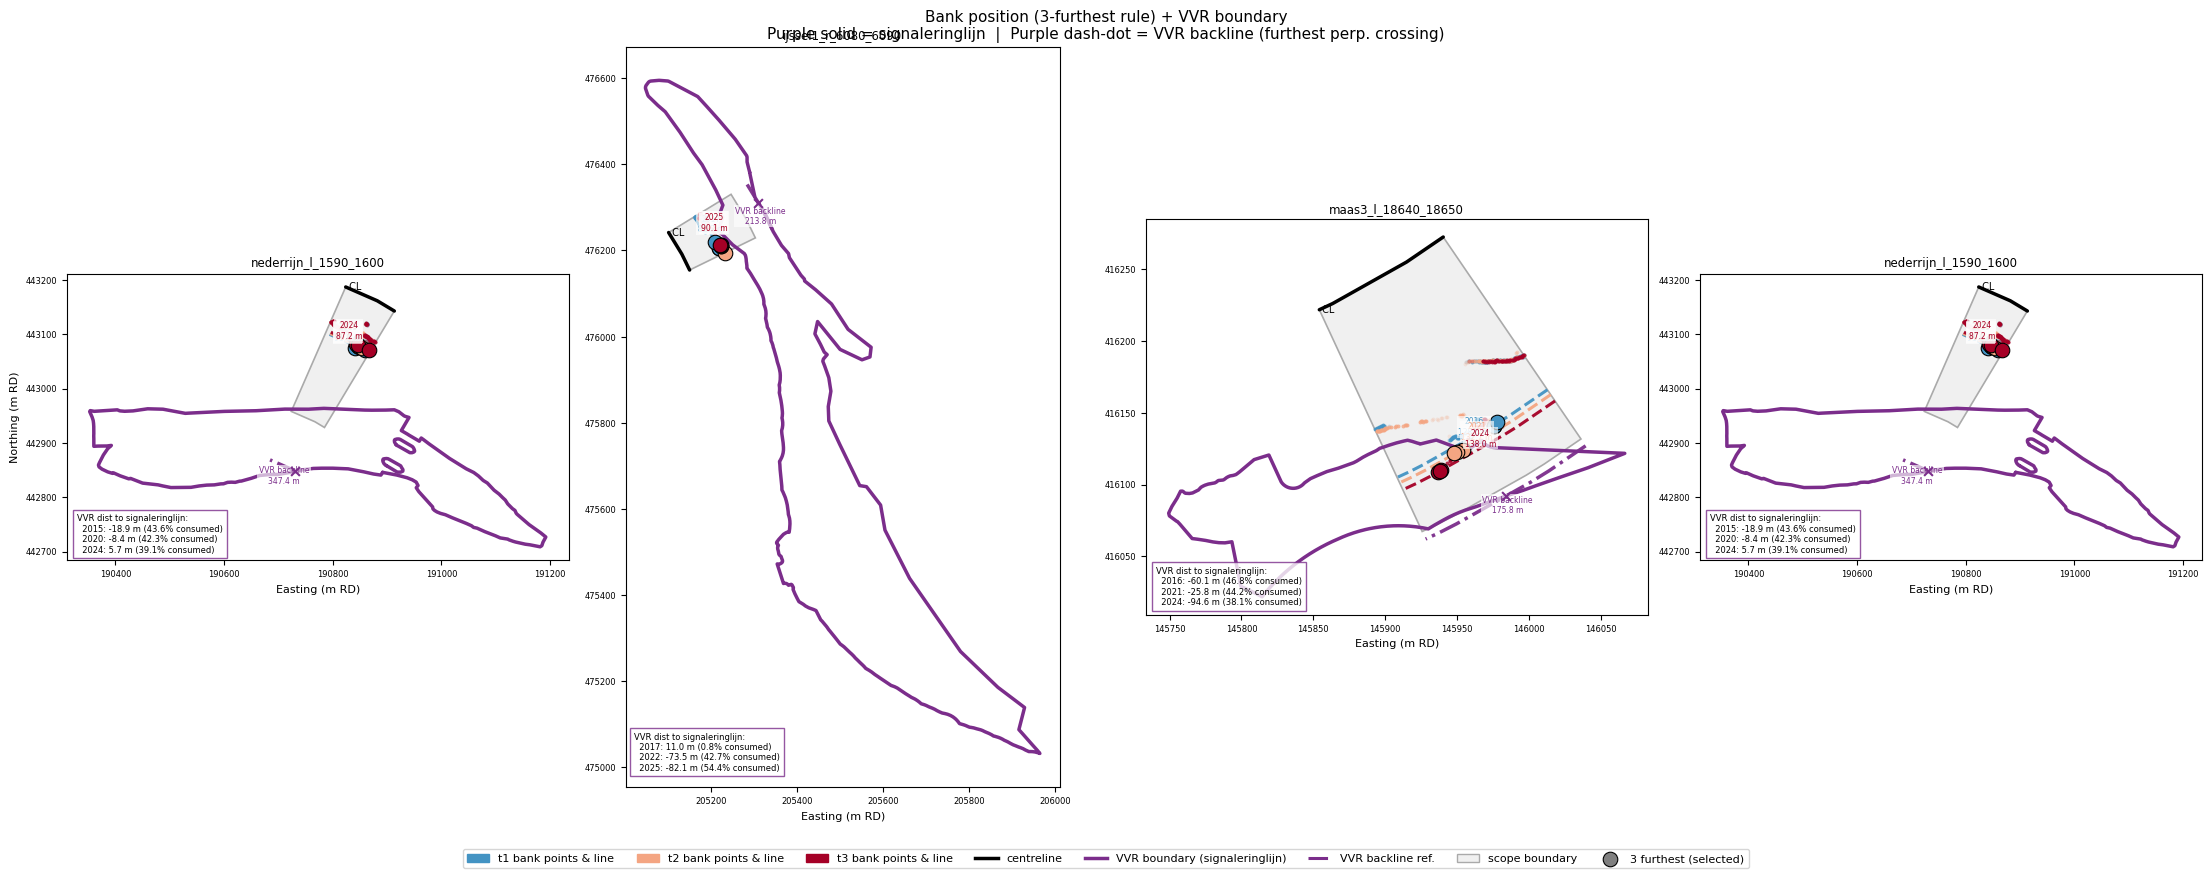

In [10]:
YEAR_COLORS  = ['#4393c3', '#f4a582', '#a50026']
STATUS_ALPHA = {'OK': 0.80, 'OUTLIER': 0.20, 'UNCERTAIN': 0.40}
VVR_COLOR    = '#7b2d8b'   # purple for the VVR boundary

fig, axes = plt.subplots(1, len(vvr_selected),
                         figsize=(5.5 * len(vvr_selected), 8),
                         constrained_layout=True)

for col, loc_id in enumerate(vvr_selected):
    ax    = axes[col]
    grp   = pts[pts['location_id'] == loc_id].copy()
    dates = sorted(grp['dtm_date'].unique())
    cline = cl_lookup.get(loc_id)
    sgeom = scope_lookup.get(loc_id)

    ax.set_aspect('equal')
    ax.set_title(loc_id, fontsize=8.5, pad=5)
    ax.tick_params(labelsize=6)
    if col == 0:
        ax.set_ylabel('Northing (m RD)', fontsize=8)
    ax.set_xlabel('Easting (m RD)', fontsize=8)

    # ── scope boundary ────────────────────────────────────────────────
    if sgeom is not None:
        bx, by = sgeom.exterior.xy
        ax.fill(bx, by, fc='#f0f0f0', ec='#aaaaaa', lw=1.2, zorder=1)

    # ── VVR boundary lines whose geometry intersects the scope polygon ───
    if sgeom is not None:
        local_vvr = vvr_ln[vvr_ln.intersects(sgeom)]
    else:
        local_vvr = vvr_ln.iloc[0:0]  # empty — no scope polygon available

    for _, vrow in local_vvr.iterrows():
        geom = vrow.geometry
        # flatten to individual line/ring segments regardless of geometry type
        from shapely.geometry import MultiLineString, MultiPolygon, Polygon, LineString, GeometryCollection
        if geom is None or geom.is_empty:
            continue
        if geom.geom_type in ('LineString', 'LinearRing'):
            parts = [geom]
        elif geom.geom_type == 'MultiLineString':
            parts = list(geom.geoms)
        elif geom.geom_type == 'Polygon':
            parts = [geom.exterior]
        elif geom.geom_type == 'MultiPolygon':
            parts = [p.exterior for p in geom.geoms]
        elif geom.geom_type == 'GeometryCollection':
            parts = [g for g in geom.geoms if not g.is_empty]
        else:
            parts = [geom]
        for part in parts:
            try:
                vx, vy = part.xy
                ax.plot(vx, vy, color=VVR_COLOR, linewidth=2.5, zorder=7,
                        linestyle='-', solid_capstyle='round')
            except NotImplementedError:
                pass

    # ── centreline ────────────────────────────────────────────────────
    if cline is not None:
        xs, ys = cline.xy
        ax.plot(xs, ys, color='black', linewidth=2.5, zorder=5,
                solid_capstyle='round')
        ax.text(xs[-1], ys[-1], ' CL', fontsize=7, color='black',
                va='center', zorder=6)

    # ── bank points + 3-furthest parallel lines ───────────────────────
    for d_idx, date in enumerate(dates):
        color  = YEAR_COLORS[d_idx]
        yr_grp = grp[grp['dtm_date'] == date]

        for status, sub in yr_grp.groupby('status'):
            alpha = STATUS_ALPHA.get(status, 0.3)
            ax.scatter(sub.geometry.x, sub.geometry.y,
                       c=color, s=8, alpha=alpha, linewidths=0, zorder=3)

        chosen    = yr_grp.nlargest(3, 'dist')
        mean_dist = chosen['dist'].mean()

        ax.scatter(chosen.geometry.x, chosen.geometry.y,
                   c=color, s=110, edgecolors='black', linewidths=0.8, zorder=8)

        if cline is not None:
            offset_line = offset_toward_points(cline, mean_dist, chosen.geometry)
            if offset_line is not None and not offset_line.is_empty:
                ox, oy = offset_line.xy
                ax.plot(ox, oy, color=color, linewidth=2.2, linestyle='--',
                        zorder=6, alpha=0.95)
                mid = offset_line.interpolate(0.5, normalized=True)
                ax.text(mid.x, mid.y, f'{date}\n{mean_dist:.1f} m',
                        fontsize=5.5, color=color, ha='center', va='bottom',
                        zorder=9,
                        bbox=dict(fc='white', ec='none', alpha=0.65, pad=1))

    # ── VVR backline reference line ───────────────────────────────────
    if cline is not None and not local_vvr.empty:
        from shapely.ops import unary_union
        vvr_union = unary_union(local_vvr.geometry)
        vvr_dist, p_vvr = vvr_backline_distance(cline, vvr_union)
        if vvr_dist is not None:
            vvr_ref = offset_toward_points(cline, vvr_dist, gpd.GeoSeries([p_vvr]))
            if vvr_ref is not None and not vvr_ref.is_empty:
                rx, ry = vvr_ref.xy
                ax.plot(rx, ry, color=VVR_COLOR, linewidth=2.5, linestyle='-.',
                        zorder=7, alpha=0.95)
                mid_vvr = vvr_ref.interpolate(0.5, normalized=True)
                ax.text(mid_vvr.x, mid_vvr.y, f'VVR backline\n{vvr_dist:.1f} m',
                        fontsize=5.5, color=VVR_COLOR, ha='center', va='top',
                        zorder=9,
                        bbox=dict(fc='white', ec='none', alpha=0.65, pad=1))
            ax.scatter([p_vvr.x], [p_vvr.y], c=VVR_COLOR, s=40, zorder=10, marker='x')

    # ── annotate VVR distance from time-series ────────────────────────
    region_vvr = vvr_ts[vvr_ts['position_id'] == loc_id].sort_values('annum')
    if not region_vvr.empty:
        lines = ['VVR dist to signaleringlijn:']
        for _, r in region_vvr.iterrows():
            lines.append(f"  {int(r['annum'])}: {r['distance_to_signaleringlijn']:.1f} m "
                         f"({r['percentage_consumed']:.1f}% consumed)")
        ax.text(0.02, 0.02, '\n'.join(lines),
                transform=ax.transAxes, fontsize=6,
                va='bottom', ha='left', zorder=10,
                bbox=dict(fc='white', ec='#7b2d8b', alpha=0.8, pad=3, lw=1))

# ── legend ─────────────────────────────────────────────────────────────────
year_patches = [
    mpatches.Patch(color=YEAR_COLORS[i], label=f't{i+1} bank points & line')
    for i in range(3)
]
other = [
    plt.Line2D([0], [0], color='black',   linewidth=2.5, label='centreline'),
    plt.Line2D([0], [0], color=VVR_COLOR, linewidth=2.5, label='VVR boundary (signaleringlijn)'),
    plt.Line2D([0], [0], color=VVR_COLOR, linewidth=2.2, linestyle='-.', label='VVR backline ref.'),
    mpatches.Patch(fc='#f0f0f0', ec='#aaaaaa',  label='scope boundary'),
    plt.scatter([], [], s=110, c='grey', edgecolors='black', lw=0.8,
                label='3 furthest (selected)'),
]
fig.legend(handles=year_patches + other,
           loc='lower center', ncol=9, fontsize=8,
           bbox_to_anchor=(0.5, -0.06), frameon=True)

fig.suptitle(
    'Bank position (3-furthest rule) + VVR boundary\n'
    'Purple solid = signaleringlijn  |  Purple dash-dot = VVR backline (furthest perp. crossing)',
    fontsize=11, y=1.02
)
plt.show()

### Interactive Folium map — bank positions + VVR boundary

One map per selected VVR region, with toggle layers:
- **Grey polygon** — scope boundary  
- **Black line** — centreline  
- **Purple line** — VVR / signaleringlijn boundary  
- **Coloured dots** — bank points per year (blue t1 / orange t2 / red t3)  
- **Coloured dashed lines** — bank position (mean of 3 furthest points) per year

In [14]:
# ── VVR boundary diagnostics ─────────────────────────────────────────────────
print('=== vvr_ln overview ===')
print(f'CRS      : {vvr_ln.crs}')
print(f'Rows     : {len(vvr_ln)}')
print(f'Columns  : {list(vvr_ln.columns)}')
print(f'Geom types: {vvr_ln.geom_type.value_counts().to_dict()}')
print(f'Bounds   : {vvr_ln.total_bounds}')
print()
_drop = [c for c in ['geometry', 'gdb_geomattr_data'] if c in vvr_ln.columns]
print(vvr_ln.head(3).drop(columns=_drop).to_string())
print()

# Check bounds of scope regions we are plotting
print('=== Scope region bounds (RD) ===')
for loc_id in vvr_selected:
    sgeom = scope_lookup.get(loc_id)
    if sgeom:
        print(f'  {loc_id}: {sgeom.bounds}')

print()

# Try the spatial filter for each region and report counts
print('=== VVR lines found per region (buffer=200 m) ===')
for loc_id in vvr_selected:
    sgeom = scope_lookup.get(loc_id)
    if sgeom is not None:
        # ensure CRS alignment before spatial filter
        sgeom_check = sgeom
        hit = vvr_ln[vvr_ln.intersects(sgeom_check.buffer(200))]
        print(f'  {loc_id}: {len(hit)} VVR lines found')
        if len(hit):
            print(f'    sample geom type: {hit.iloc[0].geometry.geom_type}')
            print(f'    sample bounds   : {hit.iloc[0].geometry.bounds}')
    else:
        print(f'  {loc_id}: no scope geometry found in scope_lookup')

print()

# Sample a raw VVR coord and convert to WGS84 to verify reprojection
sample_geom = vvr_ln.iloc[0].geometry
from shapely.ops import transform as shp_transform
sample_wgs = rd_to_wgs84(sample_geom)
print('=== Reprojection sanity check ===')
print(f'First VVR geom type: {sample_geom.geom_type}')
print(f'RD bounds  : {sample_geom.bounds}')
print(f'WGS84 bounds: {sample_wgs.bounds}')
print('(WGS84 coordinates should be roughly lon 3–7, lat 51–53 for NL)')

=== vvr_ln overview ===
CRS      : EPSG:28992
Rows     : 105
Columns  : ['datummutatie', 'bron', 'status', 'objectnaam', 'rwsdienst', 'waterlichaam', 'opmerkingen', 'gdb_geomattr_data', 'geometry']
Geom types: {'MultiLineString': 105}
Bounds   : [ 79187.2075 315918.2282 211549.6833 511167.213 ]

               datummutatie         bron       status                        objectnaam rwsdienst       waterlichaam opmerkingen
0 2022-07-04 00:00:00+02:00  GIS analyse  Vastgesteld  KRW Waal Klomperwaard- nevengeul        ON  Boven-Rijn - Waal        None
1 2022-07-04 00:00:00+02:00  GIS analyse  Vastgesteld           Loenensche Buitenpolder        ON  Boven-Rijn - Waal        None
2 2022-07-04 00:00:00+02:00  GIS analyse  Vastgesteld                     Ewijkse plaat        ON  Boven-Rijn - Waal        None

=== Scope region bounds (RD) ===
  nederrijn_l_1590_1600: (190723.69408941173, 442928.3412147787, 190913.38293278872, 443186.971468045)
  ijssel1_r_6080_6090: (205101.5847371208, 476154.

NameError: name 'rd_to_wgs84' is not defined

In [15]:
import folium
import json
from shapely.geometry import mapping, MultiLineString
from shapely.ops import transform as shp_transform
import pyproj

RD    = pyproj.CRS('EPSG:28992')
WGS84 = pyproj.CRS('EPSG:4326')
to_wgs84 = pyproj.Transformer.from_crs(RD, WGS84, always_xy=True).transform

def rd_to_wgs84(geom):
    """Reproject a Shapely geometry from RD to WGS84."""
    return shp_transform(to_wgs84, geom)

YEAR_HEX     = ['#4393c3', '#f4a582', '#a50026']   # t1 blue, t2 salmon, t3 red
VVR_HEX      = '#7b2d8b'


def make_map_for_region(loc_id):
    grp   = pts[pts['location_id'] == loc_id].copy()
    dates = sorted(grp['dtm_date'].unique())
    cline = cl_lookup.get(loc_id)
    sgeom = scope_lookup.get(loc_id)

    # ── centre map on scope centroid ─────────────────────────────────────────
    centre_rd  = sgeom.centroid if sgeom else grp.geometry.union_all().centroid
    centre_wgs = rd_to_wgs84(centre_rd)
    m = folium.Map(location=[centre_wgs.y, centre_wgs.x], zoom_start=16,
                   tiles='OpenStreetMap')

    # ── scope boundary ───────────────────────────────────────────────────────
    if sgeom is not None:
        scope_wgs = rd_to_wgs84(sgeom)
        folium.GeoJson(
            mapping(scope_wgs),
            name='Scope boundary',
            style_function=lambda _: {'color': '#888888', 'weight': 2,
                                      'fillColor': '#cccccc', 'fillOpacity': 0.15},
        ).add_to(m)

    # ── VVR boundary lines ───────────────────────────────────────────────────
    if sgeom is not None:
        local_vvr = vvr_ln[vvr_ln.intersects(sgeom)]
    else:
        local_vvr = vvr_ln.iloc[0:0]  # no scope polygon — skip VVR

    vvr_fg = folium.FeatureGroup(name='VVR boundary (signaleringlijn)')
    for _, vrow in local_vvr.iterrows():
        geom = vrow.geometry
        if geom is None or geom.is_empty:
            continue
        geom_wgs = rd_to_wgs84(geom)
        folium.GeoJson(
            mapping(geom_wgs),
            style_function=lambda _: {'color': VVR_HEX, 'weight': 3.5},
        ).add_to(vvr_fg)
    vvr_fg.add_to(m)

    # ── centreline ───────────────────────────────────────────────────────────
    if cline is not None:
        cl_wgs = rd_to_wgs84(cline)
        folium.GeoJson(
            mapping(cl_wgs),
            name='Centreline',
            style_function=lambda _: {'color': 'black', 'weight': 2.5},
        ).add_to(m)

    # ── bank points + 3-furthest lines ───────────────────────────────────────
    for d_idx, date in enumerate(dates):
        color  = YEAR_HEX[d_idx]
        yr_grp = grp[grp['dtm_date'] == date]
        label  = f't{d_idx+1} ({date})'

        pts_fg = folium.FeatureGroup(name=f'Bank points {label}')
        for _, row in yr_grp.iterrows():
            pt_wgs = rd_to_wgs84(row.geometry)
            opacity = {'OK': 0.85, 'OUTLIER': 0.25, 'UNCERTAIN': 0.45}.get(row['status'], 0.4)
            folium.CircleMarker(
                location=[pt_wgs.y, pt_wgs.x],
                radius=3, color=color, fill=True, fill_color=color,
                fill_opacity=opacity, weight=0,
                tooltip=f"{row['status']}  dist={row['dist']:.1f} m  {date}",
            ).add_to(pts_fg)
        pts_fg.add_to(m)

        # 3-furthest parallel line
        chosen    = yr_grp.nlargest(3, 'dist')
        mean_dist = chosen['dist'].mean()
        if cline is not None:
            offset_line = offset_toward_points(cline, mean_dist, chosen.geometry)
            if offset_line is not None and not offset_line.is_empty:
                ol_wgs = rd_to_wgs84(offset_line)
                line_fg = folium.FeatureGroup(name=f'Bank position {label}')
                folium.GeoJson(
                    mapping(ol_wgs),
                    style_function=lambda _, c=color: {
                        'color': c, 'weight': 3, 'dashArray': '8 5'
                    },
                    tooltip=f'{label}  mean dist = {mean_dist:.1f} m',
                ).add_to(line_fg)
                # also mark the 3 selected points
                for _, r in chosen.iterrows():
                    pt_wgs = rd_to_wgs84(r.geometry)
                    folium.CircleMarker(
                        location=[pt_wgs.y, pt_wgs.x],
                        radius=6, color='black', fill=True, fill_color=color,
                        fill_opacity=1.0, weight=1.5,
                        tooltip=f'SELECTED  dist={r["dist"]:.1f} m  {r["status"]}',
                    ).add_to(line_fg)
                line_fg.add_to(m)

    # ── VVR backline reference line ───────────────────────────────────────────
    # Use vvr_backline_distance: the furthest crossing of the perpendicular ray
    # from the CL midpoint with the VVR geometry (outer edge of the VVR band).
    if cline is not None and not local_vvr.empty:
        from shapely.ops import unary_union
        vvr_union             = unary_union(local_vvr.geometry)
        vvr_dist, p_vvr       = vvr_backline_distance(cline, vvr_union)
        if vvr_dist is not None:
            vvr_ref = offset_toward_points(cline, vvr_dist, gpd.GeoSeries([p_vvr]))
            if vvr_ref is not None and not vvr_ref.is_empty:
                p_vvr_wgs  = rd_to_wgs84(p_vvr)
                vvr_ref_fg = folium.FeatureGroup(name='VVR backline reference')
                folium.GeoJson(
                    mapping(rd_to_wgs84(vvr_ref)),
                    style_function=lambda _: {
                        'color': VVR_HEX, 'weight': 3, 'dashArray': '10 4'
                    },
                    tooltip=f'VVR backline distance = {vvr_dist:.1f} m',
                ).add_to(vvr_ref_fg)
                folium.CircleMarker(
                    location=[p_vvr_wgs.y, p_vvr_wgs.x],
                    radius=5, color=VVR_HEX, fill=True, fill_color=VVR_HEX,
                    fill_opacity=1.0, weight=1.5,
                    tooltip=f'VVR backline point  dist = {vvr_dist:.1f} m from CL',
                ).add_to(vvr_ref_fg)
                vvr_ref_fg.add_to(m)

    # ── WOCU implied bank positions (from distance_to_signaleringlijn) ──────
    # The WOCU pipeline reports how far the bank is from the signaleringlijn.
    # Inverting this gives the bank's distance from the centreline:
    #   wocu_bank_dist = vvr_backline_dist − distance_to_signaleringlijn
    # A negative distance_to_signaleringlijn means the bank already breached the limit.
    region_vvr = vvr_ts[vvr_ts['position_id'] == loc_id].sort_values('annum')
    if vvr_dist is not None and not region_vvr.empty:
        WOCU_HEX   = '#2ca02c'
        WOCU_YEARS = sorted(region_vvr['annum'].unique())
        year_palette = ['#b2df8a', '#33a02c', '#006d2c']  # light → dark green per year
        wocu_fg = folium.FeatureGroup(name='WOCU implied bank pos (AHN area)')
        for i, (_, r) in enumerate(region_vvr.iterrows()):
            wocu_bank_dist = vvr_dist - r['distance_to_signaleringlijn']
            col = year_palette[min(i, len(year_palette) - 1)]
            yr  = int(r['annum'])
            if wocu_bank_dist > 0 and p_vvr is not None:
                wocu_line = offset_toward_points(cline, wocu_bank_dist, gpd.GeoSeries([p_vvr]))
                if wocu_line is not None and not wocu_line.is_empty:
                    dist_sig = r['distance_to_signaleringlijn']
                    breach   = ' ⚠ BREACHED' if dist_sig < 0 else ''
                    folium.GeoJson(
                        mapping(rd_to_wgs84(wocu_line)),
                        style_function=lambda _, c=col: {
                            'color': c, 'weight': 2.5, 'dashArray': '6 3'
                        },
                        tooltip=(f'WOCU bank pos {yr}: {wocu_bank_dist:.1f} m from CL  |  '
                                 f'dist to signaleringlijn = {dist_sig:.1f} m{breach}'),
                    ).add_to(wocu_fg)
        wocu_fg.add_to(m)

    # ── VVR distance inset as a DivIcon marker ───────────────────────────────
    region_vvr = vvr_ts[vvr_ts['position_id'] == loc_id].sort_values('annum')
    if not region_vvr.empty:
        html_lines = ['<b>VVR dist to signaleringlijn</b><br>']
        for _, r in region_vvr.iterrows():
            html_lines.append(
                f"{int(r['annum'])}: <b>{r['distance_to_signaleringlijn']:.1f} m</b> "
                f"({r['percentage_consumed']:.1f}% consumed)<br>"
            )
        popup_html = ''.join(html_lines)
        folium.Marker(
            location=[centre_wgs.y, centre_wgs.x],
            icon=folium.DivIcon(
                html=f'<div style="background:white;border:2px solid {VVR_HEX};'
                     f'padding:4px;font-size:11px;border-radius:4px;white-space:nowrap">'
                     f'{popup_html}</div>',
                icon_size=(260, 80), icon_anchor=(0, 0)
            ),
        ).add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    return m

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# Discussion map — three candidate VVR reference distances
# Region: maas3_l_18640_18650
# ──────────────────────────────────────────────────────────────────────────────
#  Option A — first (nearest) crossing of perpendicular ray with VVR  → frontline
#  Option B — last (furthest) crossing of perpendicular ray with VVR  → backline
#  Option C — point on VVR with maximum distance to centreline
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
from shapely.geometry import LineString as SLineString, Point as SPoint
from shapely.ops import unary_union

DISCUSS_ID = 'maas3_l_18640_18650'
grp   = pts[pts['location_id'] == DISCUSS_ID].copy()
cline = cl_lookup.get(DISCUSS_ID)
sgeom = scope_lookup.get(DISCUSS_ID)
dates = sorted(grp['dtm_date'].unique())

if sgeom is not None:
    local_vvr = vvr_ln[vvr_ln.intersects(sgeom)]
else:
    local_vvr = vvr_ln.iloc[0:0]
vvr_union = unary_union(local_vvr.geometry) if not local_vvr.empty else None

# ── perpendicular ray from CL midpoint in both directions ────────────────────
RAY_LEN   = 5000
mid_param = cline.length / 2
mid_pt    = cline.interpolate(mid_param)
eps       = min(1.0, cline.length * 0.01)
pt_before = cline.interpolate(max(0, mid_param - eps))
pt_after  = cline.interpolate(min(cline.length, mid_param + eps))
dx = pt_after.x - pt_before.x
dy = pt_after.y - pt_before.y
dn = np.hypot(dx, dy)
px, py = -dy / dn, dx / dn   # left perpendicular

def make_ray(ox, oy, ddx, ddy, length):
    return SLineString([(ox, oy), (ox + ddx * length, oy + ddy * length)])

ray_L = make_ray(mid_pt.x, mid_pt.y,  px,  py, RAY_LEN)
ray_R = make_ray(mid_pt.x, mid_pt.y, -px, -py, RAY_LEN)

def sorted_ray_crossings(ray, geom):
    """All Point intersections of ray with geom, sorted nearest → furthest from ray origin."""
    if geom is None:
        return []
    inter = ray.intersection(geom)
    if inter.is_empty:
        return []
    origin = SPoint(ray.coords[0])
    if inter.geom_type == 'Point':
        candidates = [inter]
    elif inter.geom_type == 'MultiPoint':
        candidates = list(inter.geoms)
    elif inter.geom_type == 'GeometryCollection':
        candidates = [g for g in inter.geoms if g.geom_type == 'Point']
    else:
        candidates = [SPoint(c) for c in inter.coords] if hasattr(inter, 'coords') else []
    return sorted(candidates, key=lambda p: origin.distance(p))

crossings_L = sorted_ray_crossings(ray_L, vvr_union)
crossings_R = sorted_ray_crossings(ray_R, vvr_union)

# Use whichever side the VVR is on (more crossings = right side)
if len(crossings_L) >= len(crossings_R):
    crossings, ray_used = crossings_L, ray_L
else:
    crossings, ray_used = crossings_R, ray_R

option_A = crossings[0]  if len(crossings) > 0 else None   # nearest crossing  (front)
option_B = crossings[-1] if len(crossings) > 1 else None   # furthest crossing (back)

# ── Option C: vertex on VVR geometry with maximum distance to the CL ─────────
def extract_coords(geom):
    if geom is None:
        return []
    if geom.geom_type in ('LineString', 'LinearRing'):
        return list(geom.coords)
    elif geom.geom_type == 'MultiLineString':
        return [c for g in geom.geoms for c in g.coords]
    elif geom.geom_type == 'GeometryCollection':
        return [c for g in geom.geoms for c in extract_coords(g)]
    return []

all_coords = extract_coords(vvr_union) if vvr_union else []
if all_coords:
    farthest = max(all_coords, key=lambda c: cline.distance(SPoint(c)))
    option_C = SPoint(farthest)
else:
    option_C = None

# ── perpendicular distances + offset reference lines ─────────────────────────
def dist_and_line(pt):
    if pt is None:
        return None, None
    d = cline.distance(pt)
    return d, offset_toward_points(cline, d, gpd.GeoSeries([pt]))

dist_A, line_A = dist_and_line(option_A)
dist_B, line_B = dist_and_line(option_B)
dist_C, line_C = dist_and_line(option_C)

for lbl, d in [('A — first crossing  (frontline)', dist_A),
               ('B — last crossing   (backline) ', dist_B),
               ('C — farthest vertex             ', dist_C)]:
    print(f'  Option {lbl}: {d:.1f} m' if d is not None else f'  Option {lbl}: not found')

# ── build Folium map ──────────────────────────────────────────────────────────
OPT_COLORS = {'A': '#e41a1c', 'B': '#ff7f00', 'C': '#4daf4a'}
OPT_LABELS = {
    'A': f'Option A — first crossing (frontline)  {dist_A:.1f} m' if dist_A else 'Option A',
    'B': f'Option B — last crossing  (backline)   {dist_B:.1f} m' if dist_B else 'Option B',
    'C': f'Option C — farthest VVR vertex         {dist_C:.1f} m' if dist_C else 'Option C',
}

centre_wgs = rd_to_wgs84(sgeom.centroid if sgeom else cline.centroid)
m_disc = folium.Map(location=[centre_wgs.y, centre_wgs.x], zoom_start=15,
                    tiles='CartoDB positron')

# scope boundary
if sgeom is not None:
    folium.GeoJson(
        mapping(rd_to_wgs84(sgeom)),
        name='Scope boundary',
        style_function=lambda _: {
            'fillColor': '#f0f0f0', 'color': '#aaaaaa', 'weight': 2, 'fillOpacity': 0.35
        },
    ).add_to(m_disc)

# VVR actual boundary
vvr_fg = folium.FeatureGroup(name='VVR boundary (signaleringlijn)')
for _, vrow in local_vvr.iterrows():
    geom = vrow.geometry
    if geom and not geom.is_empty:
        folium.GeoJson(
            mapping(rd_to_wgs84(geom)),
            style_function=lambda _: {'color': VVR_HEX, 'weight': 4},
        ).add_to(vvr_fg)
vvr_fg.add_to(m_disc)

# centreline
if cline is not None:
    folium.GeoJson(
        mapping(rd_to_wgs84(cline)),
        name='Centreline',
        style_function=lambda _: {'color': 'black', 'weight': 2.5},
    ).add_to(m_disc)

# perpendicular ray (grey dashed)
if ray_used is not None:
    folium.GeoJson(
        mapping(rd_to_wgs84(ray_used)),
        name='Perpendicular ray from CL midpoint',
        style_function=lambda _: {'color': '#888888', 'weight': 1.5, 'dashArray': '6 3'},
    ).add_to(m_disc)

# Options A, B, C — reference point + offset line
for key, pt, line, dist in [
    ('A', option_A, line_A, dist_A),
    ('B', option_B, line_B, dist_B),
    ('C', option_C, line_C, dist_C),
]:
    if pt is None:
        continue
    col = OPT_COLORS[key]
    fg  = folium.FeatureGroup(name=OPT_LABELS[key])
    pt_wgs = rd_to_wgs84(pt)
    folium.CircleMarker(
        location=[pt_wgs.y, pt_wgs.x],
        radius=9, color=col, fill=True, fill_color=col,
        fill_opacity=0.9, weight=2,
        tooltip=OPT_LABELS[key],
    ).add_to(fg)
    if line is not None and not line.is_empty:
        folium.GeoJson(
            mapping(rd_to_wgs84(line)),
            style_function=lambda _, c=col: {'color': c, 'weight': 3, 'dashArray': '10 4'},
            tooltip=OPT_LABELS[key],
        ).add_to(fg)
    fg.add_to(m_disc)

# ── WOCU implied bank positions (from distance_to_signaleringlijn) ────────────
# Invert the WOCU metric: bank_dist_from_CL = vvr_backline_dist − dist_to_sig
# Negative dist_to_signaleringlijn means the bank has already breached the VVR limit.
region_vvr_ts = vvr_ts[vvr_ts['position_id'] == DISCUSS_ID].sort_values('annum')
if dist_B is not None and not region_vvr_ts.empty:
    WOCU_PALETTE = ['#b2df8a', '#33a02c', '#006d2c']   # light→dark green per year
    wocu_fg = folium.FeatureGroup(name='WOCU implied bank pos (AHN area, per year)')
    for i, (_, r) in enumerate(region_vvr_ts.iterrows()):
        wocu_bank_dist = dist_B - r['distance_to_signaleringlijn']
        col = WOCU_PALETTE[min(i, len(WOCU_PALETTE) - 1)]
        yr  = int(r['annum'])
        dist_sig = r['distance_to_signaleringlijn']
        breach = ' ⚠ BREACHED' if dist_sig < 0 else ''
        if wocu_bank_dist > 0 and option_B is not None:
            wocu_line = offset_toward_points(cline, wocu_bank_dist, gpd.GeoSeries([option_B]))
            if wocu_line is not None and not wocu_line.is_empty:
                folium.GeoJson(
                    mapping(rd_to_wgs84(wocu_line)),
                    style_function=lambda _, c=col: {
                        'color': c, 'weight': 2.5, 'dashArray': '6 3'
                    },
                    tooltip=(f'WOCU bank pos {yr}: {wocu_bank_dist:.1f} m from CL  |  '
                             f'dist to signaleringlijn = {dist_sig:.1f} m{breach}'),
                ).add_to(wocu_fg)
    wocu_fg.add_to(m_disc)
    print(f'\nWOCU implied bank positions (dist from CL = Option-B backline − dist_to_sig):')
    for _, r in region_vvr_ts.iterrows():
        d = dist_B - r['distance_to_signaleringlijn']
        breach = '  ⚠ BREACHED' if r['distance_to_signaleringlijn'] < 0 else ''
        print(f"  {int(r['annum'])}: {d:.1f} m from CL  "
              f"(dist_to_sig = {r['distance_to_signaleringlijn']:.1f} m){breach}")

# latest-year bank points for spatial context
last_date = dates[-1]
yr_grp    = grp[grp['dtm_date'] == last_date]
pts_fg    = folium.FeatureGroup(name=f'Bank points (latest: {last_date})')
for _, row in yr_grp.iterrows():
    pt_wgs = rd_to_wgs84(row.geometry)
    folium.CircleMarker(
        location=[pt_wgs.y, pt_wgs.x],
        radius=4, color='#a50026', fill=True, fill_color='#a50026',
        fill_opacity=0.7, weight=1,
        tooltip=f'{row["status"]}  dist={row["dist"]:.1f} m',
    ).add_to(pts_fg)
pts_fg.add_to(m_disc)

folium.LayerControl(collapsed=False).add_to(m_disc)
display(m_disc)

  Option A — first crossing  (frontline): 134.2 m
  Option B — last crossing   (backline) : 175.8 m
  Option C — farthest vertex             : 203.5 m

WOCU implied bank positions (dist from CL = Option-B backline − dist_to_sig):
  2016: 235.9 m from CL  (dist_to_sig = -60.1 m)  ⚠ BREACHED
  2021: 201.5 m from CL  (dist_to_sig = -25.8 m)  ⚠ BREACHED
  2024: 270.3 m from CL  (dist_to_sig = -94.6 m)  ⚠ BREACHED


In [17]:
# Render one map per selected VVR region
for loc_id in vvr_selected:
    print(f'\n{"─"*60}')
    print(f'  {loc_id}')
    print(f'{"─"*60}')
    display(make_map_for_region(loc_id))


────────────────────────────────────────────────────────────
  nederrijn_l_1590_1600
────────────────────────────────────────────────────────────



────────────────────────────────────────────────────────────
  ijssel1_r_6080_6090
────────────────────────────────────────────────────────────



────────────────────────────────────────────────────────────
  maas3_l_18640_18650
────────────────────────────────────────────────────────────



────────────────────────────────────────────────────────────
  nederrijn_l_1590_1600
────────────────────────────────────────────────────────────
